# Quantum Tic Tac Toe Game

In [80]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
import numpy as np 
import matplotlib.pyplot as plt
import random
from qiskit.visualization import plot_histogram
%matplotlib inline

## What we are doing :
We create the game structure:
- 9 qubits - 9 board cell(3 X 3 Grid)
- Each qubit represent Quantum game position
- We also store player moves 

In [81]:
class QuantumTicTacToe:
    def __init__(self):
        self.board=[" "]*9
        self.circuit = QuantumCircuit(9,9)
        self.used_cells=set()

## Quantum Player Move(Player1)

In [82]:
def quantum_move(self):
   available=[i for i in range(9) 
              if i not in self.used_cells]
   if len(available)==0:
      return
   cell=random.choice(available)
   self.circuit.h(int(cell))
   self.board[cell]="Q"
   self.used_cells.add(cell)
   print("Quantum played at:",cell)
QuantumTicTacToe.quantum_move=quantum_move


# Human Move(Player 2)

In [83]:
def human_move(self,cell):
    cell=int(cell)
    if cell in self.used_cells:
        print("Cell already used")
        return False
    self.circuit.x(int(cell))
    self.board[cell]="H"
    self.used_cells.add(cell)
    return True
QuantumTicTacToe.human_move=human_move

In [84]:
def collapse(self):
    self.circuit.measure(range(9),range(9))
    simulator=AerSimulator()
    compiled=transpile(self.circuit,simulator)
    result=simulator.run(compiled,shots=1).result()
    counts=result.get_counts()
    return list(counts.keys())[0]
#QuantumTicTacToe.collapse=collapse

## Show Board

In [85]:
def show_board(self):
    b=self.board
    for i in range(0,3,9):
        print(b[i],b[i+1],b[i+2])
    print("\n")
QuantumTicTacToe.show_board=show_board

## Run Game

In [ ]:
game = QuantumTicTacToe()
for i in range(5):
    print(f"\n  Round{i+1}")
    game.quantum_move()
    game.show_board()
    success=False
    for i in range(3):

        try:
            cell=int(input("Your move(0-8):"))
            if cell<0 or cell>8:
                print("enter number between 0 and 8")
                continue
            if cell in game.used_cells:
                print("cell alredy used")
                continue
            game.human_move(cell)
            success=True
            break
        except:
            print("Invalid input")
    if not success:
        print("too many Invalid attempts")
        break


    game.show_board()


  Round1
Quantum played at: 4
     




## collapse Quantum State

In [ ]:
def collapse(self):
    simulator=AerSimulator()
    self.circuit.measure(range(9),range(9))
    compiled=transpile(self.circuit,simulator)
    result=simulator.run(compiled,shots=1).result()
    counts=result.get_counts()
    return list(counts.keys())[0]
QuantumTicTacToe.collapse=collapse

## Final board

In [ ]:
def displaty_final(binary_string):
    board=["Q" if b=="1" else "H" for b in binary_string]
    print("\n final Board:\n")
    for i in range(0,9,3):
        print(board[i],board[i+1],board[i+2])
    return board

## Winner Check

In [ ]:
def check_winner(board):
    wins=[
        (0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)
    ]
    for a,b,c in wins:
        if board[a]==board[b]==board[c]:
            return board[a]
    return None

In [ ]:
## End Game
result=game.collapse()
board=displaty_final(result)
winner=check_winner(board)
if winner=="Q":
    print("Quantum System Wins!")
elif winner =="H":
    print("You win!")
else:
    print("Draw!")


 final Board:

H Q Q
Q Q Q
H H Q
Quantum System Wins!


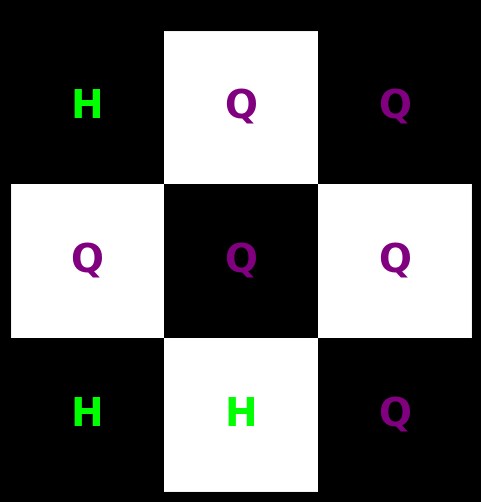

In [ ]:
def visualize(board,winner=None):
    grid=np.array(board).reshape(3,3)
    fig,ax=plt.subplots(figsize=(6,6))

    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    ax.set_title("Quantum Tic Tac Toe result")
    ax.imshow([[0,1,0],[1,0,1],[0,1,0]],cmap="gray")
    for i in range(3):
        for j in range(3):
            symbol=grid[i][j]
            if symbol=="Q":
                color="Purple"
            else:
                color="lime"
            ax.text(j,i,symbol,ha="center",va="center",color=color,fontsize=28,fontweight='bold')
    if winner=="Q":
        title="Quantum System Wins!"
        title_color="purple"
    elif winner=="H":
        title="Human Wins!"
        title_color="lime"
    else:
        title="Quantum draw!"
        title_color="white"
        ax.set_title(title,color=title_color,fontsize=18)
    ax.set_xticks(np.arange(-.5,3,1),minor=True)
    ax.set_yticks(np.arange(-.5,3,1),minor=True)
    ax.grid(which='minor',color='white',linewidth=2)
    ax.tick_params(which='both',bottom=False,left=False,labelbottom=False,labelleft=False)
    plt.show()
visualize(board,winner)

011011001
Quantum Probability Distribution:

Probability:,0.0244


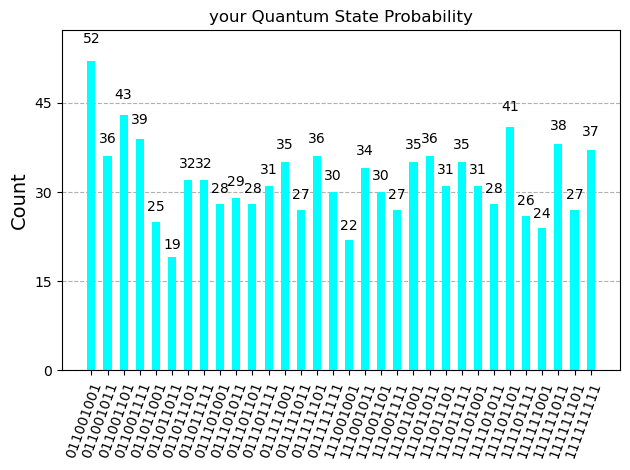

In [ ]:
## plot result

def quantum_histogram(game,final_state):
    simulator=AerSimulator()
    qc=game.circuit.copy()
    qc.measure(range(9),range(9))
    compiled =transpile(qc,simulator)
    result=simulator.run(compiled,shots=1024).result()
    counts=result.get_counts()
    print("Quantum Probability Distribution:\n")
    if final_state in counts:
        probability=counts[final_state]/1024
        print(f"Probability:,{probability:.4f}")
    else:
        print("state not found")
    colors=[]
    for state in counts:
        if state==final_state:
            colors.append("magenta")
        else:
            colors.append("lightgray")
 
    plt.Figure(figsize=(14,6))
    plot_histogram(counts,color='cyan',title="your Quantum State Probability")
    plt.show()
result=game.collapse()
print(result)
quantum_histogram(game,result)

---

**Author** : Shreya Palase

**Repository**: QuantumTic-Tac-Toe(codeQubit)

**file** : QuantumTicTacToeGame.ipynb

**Date created**: 23-May-2026

<sub>© Shreya Palase- All Rights Reserved.This notebook is part of a structured learning series designed for Github publication.</sub>